## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error,root_mean_squared_error, mean_absolute_percentage_error,r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

## Load the prepared dataset

In [2]:
df = joblib.load(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(144, 10)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   #Passengers    144 non-null    int64  
 1   month          144 non-null    int32  
 2   quarter        144 non-null    int32  
 3   lag1           143 non-null    float64
 4   lag2           142 non-null    float64
 5   lag3           141 non-null    float64
 6   rolling_mean3  142 non-null    float64
 7   rolling_std3   142 non-null    float64
 8   rolling_mean6  139 non-null    float64
 9   rolling_std6   139 non-null    float64
dtypes: float64(7), int32(2), int64(1)
memory usage: 11.2 KB
None
       #Passengers       month     quarter        lag1        lag2  \
count   144.000000  144.000000  144.000000  143.000000  142.000000   
mean    280.298611    6.500000    2.500000  279.237762  278.457746   
std     119.966317    3.464102    1.121936  119.70827

## Index integrity and missing values

In [4]:
print(df.index.freq)
print(df.isnull().sum())
print(df.index.duplicated().sum())
df.bfill(inplace=True)
print(df.isnull().sum())

<MonthBegin>
#Passengers      0
month            0
quarter          0
lag1             1
lag2             2
lag3             3
rolling_mean3    2
rolling_std3     2
rolling_mean6    5
rolling_std6     5
dtype: int64
0
#Passengers      0
month            0
quarter          0
lag1             0
lag2             0
lag3             0
rolling_mean3    0
rolling_std3     0
rolling_mean6    0
rolling_std6     0
dtype: int64


## Adding a ratio feature for multiplicative seasonality

Same reasoning as the LightGBM notebook - gives the tree model a direct signal for how far the current value sits above/below its recent trend, which is what multiplicative seasonality looks like.

In [5]:
df['lag1_ratio_rolling6'] = df['lag1'] / df['rolling_mean6']

In [6]:
train, test = df.iloc[:-12,:], df.iloc[-12:,:]

x_train, y_train = train.drop(columns=['#Passengers']), train['#Passengers']
x_test, y_test = test.drop(columns=['#Passengers']), test['#Passengers']

In [7]:
print(x_train.index.freq)
print(x_train.shape)
print(x_train.isnull().sum())
train.head()

<MonthBegin>
(132, 10)
month                  0
quarter                0
lag1                   0
lag2                   0
lag3                   0
rolling_mean3          0
rolling_std3           0
rolling_mean6          0
rolling_std6           0
lag1_ratio_rolling6    0
dtype: int64


,#Passengers,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,lag1_ratio_rolling6
Month,,,,,,,,,,,
1949-01-01,112,1,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.899598
1949-02-01,118,2,1,112.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.899598
1949-03-01,132,3,1,118.0,112.0,112.0,120.666667,10.263203,124.5,8.916277,0.947791
1949-04-01,129,4,2,132.0,118.0,112.0,126.333333,7.371115,124.5,8.916277,1.060241
1949-05-01,121,5,2,129.0,132.0,118.0,127.333333,5.686241,124.5,8.916277,1.036145


## Evaluation helper

In [8]:
def model_evaluator(train,test,predictions, model:str):
  plt.figure(figsize=(10,4))
  plt.plot(train,label='train')
  plt.plot(test,label='test')
  plt.plot(predictions,label='Prediction')

  plt.legend(loc='best')
  plt.title(f'Forecast with {model}')
  plt.show()

  mae= round(mean_absolute_error(test,predictions), 2)
  mape= round(mean_absolute_percentage_error(test, predictions) , 2) * 100
  r2= round(r2_score(test, predictions), 2)
  rmse= round(root_mean_squared_error(test,predictions), 2)

  print(f'mean absolute error: {mae}')
  print(f'mean absolute percentage error: {mape}%')
  print(f'r2 score: {r2}')
  print(f'root mean squared error: {rmse}')
  values= {'mae': mae, 'mape': mape, 'r2': r2, 'rmse': rmse}
  value= pd.DataFrame(values, index=[0])
  return value

## Recursive step-ahead feature builder



In [9]:
def build_exog_row(model, history, future_dates_df, target_col="#Passengers"):

    history = history.copy()
    all_exog_rows = []
    all_predictions = []

    for date in future_dates_df.index:

        month_number = date.month
        quarter_number = date.quarter

        lag1  = history.iloc[-1]  if len(history) >= 1  else history.iloc[0]
        lag2  = history.iloc[-2]  if len(history) >= 2  else history.iloc[0]
        lag3  = history.iloc[-3]  if len(history) >= 3  else history.iloc[0]

        last_3_months  = history.iloc[-3:]  if len(history) >= 3  else history
        last_6_months  = history.iloc[-6:]  if len(history) >= 6  else history

        rolling_mean_3  = last_3_months.mean()
        rolling_std_3   = last_3_months.std() if len(last_3_months) > 1 else 0.0

        rolling_mean_6  = last_6_months.mean()
        rolling_std_6   = last_6_months.std() if len(last_6_months) > 1 else 0.0

        lag1_ratio_rolling6 = lag1 / rolling_mean_6 if rolling_mean_6 != 0 else 1.0

        one_row = pd.DataFrame({
            "month": [month_number],
            "quarter": [quarter_number],
            "lag1": [lag1],
            "lag2": [lag2],
            "lag3": [lag3],
            "rolling_mean3": [rolling_mean_3],
            "rolling_std3": [rolling_std_3],
            "rolling_mean6": [rolling_mean_6],
            "rolling_std6": [rolling_std_6],
            "lag1_ratio_rolling6": [lag1_ratio_rolling6],
        }, index=[date])

        all_exog_rows.append(one_row)

        prediction = model.predict(one_row)

        if hasattr(prediction, "iloc"):
            predicted_value = float(prediction.iloc[0])
        else:
            predicted_value = float(prediction[0])

        all_predictions.append(predicted_value)

        history.loc[date] = predicted_value

    future_exog = pd.concat(all_exog_rows)
    forecast = pd.Series(all_predictions, index=future_dates_df.index, name=target_col)

    return future_exog, forecast

## Baseline XGBoost

Fitting on `x_train`/`y_train` (real training data, no leakage risk) with default hyperparameters.

In [10]:
simple_model = XGBRegressor(random_state=42)

simple_model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

### Evaluating the baseline honestly

In [11]:
eval_dates = pd.DataFrame(index=test.index)
history = y_train

exog, simple_pred = build_exog_row(simple_model, history, eval_dates)

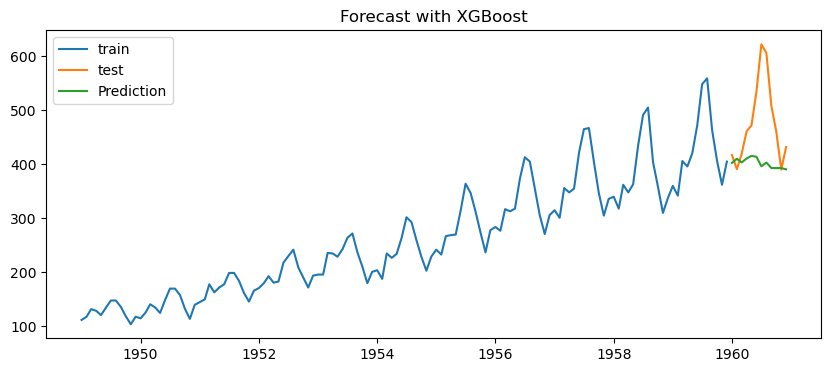

mean absolute error: 77.75
mean absolute percentage error: 15.0%
r2 score: -1.0
root mean squared error: 105.22


,mae,mape,r2,rmse
0,77.75,15.0,-1.0,105.22


In [12]:
model_evaluator(y_train,y_test,simple_pred, 'XGBoost')

## Fine-tuning XGBoost



In [13]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    "n_estimators": list(range(100, 2000, 50)),
    "max_depth": list(range(2, 9,2)),
    "learning_rate": list(np.arange(0.005, 0.305, 0.1)),
    "subsample": list(np.arange(0.5, 1.0, 0.2)),
    "colsample_bytree": list(np.arange(0.5, 1.0, 0.2)),
    "min_child_weight": list(range(1, 11,2)),
    "gamma": list(np.arange(0.0, 0.51, 0.1)),
    "reg_alpha": list(np.arange(0.0, 1.01, 0.1)),
    "reg_lambda": list(np.arange(0.0, 2.01, 0.1)),
}

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
)

In [14]:
grid= RandomizedSearchCV(xgb_model, param_dist, cv=tscv, n_jobs=-1, verbose=1,scoring="neg_root_mean_squared_error",)

In [15]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamm...
                                                      0.5, 0.6000000000000001,
                                                      0.7000000000000001, 0.8,
                                                      0.9, 1.0],
                                        'reg_lambda': [0.0, 0.1, 0.2,
                                                       0.30000000000000004, 0.4,
                                                       0.5, 0.6000000000000001,
                                                       0.7000000000000001, 0.8,
                                                       0.9, 1.0, 1.1,
                                                       1.2000000000000002, 1.3,
                                                       1.4000000000000001, 1.5,
                                                       1.6, 1.7000000000000002,
                                                       1.8, 1.9000000000000001,
                                                       2.0],
                                        'subsample': [0.5, 0.7,
                                                      0.8999999999999999]},
                   scoring='neg_root_mean_squared_error', verbose=1)

In [16]:
grid.best_estimator_

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
param= grid.best_params_

In [18]:
grid.best_score_

-41.16712433965516

In [19]:
exog, grid_pred = build_exog_row(grid, history, eval_dates)

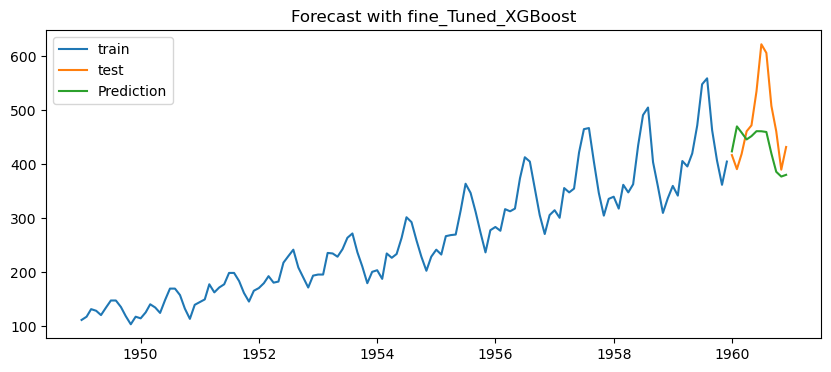

mean absolute error: 64.06
mean absolute percentage error: 13.0%
r2 score: -0.16
root mean squared error: 80.33


In [20]:
xgb_values= model_evaluator(y_train,y_test,grid_pred, 'fine_Tuned_XGBoost')

In [21]:
xgb_values.to_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\xgb_metric.csv', index=False)

## Final model

Keeping `random_state`/`objective` explicit since `grid.best_params_` only contains what was actually searched over.

In [22]:
final_model= XGBRegressor(**param, objective="reg:squarederror", random_state=42)
final_model.fit(df.drop(columns=['#Passengers']), df['#Passengers'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1500,
             n_jobs=None, num_parallel_tree=None, ...)

## Forecasting the next 12 months

Reusing the same `build_exog_row` function.

In [23]:
future_data= pd.date_range(start= '1961-01-01' , freq='MS', periods=12)
future_data= pd.Series(index= future_data)
future_data.index

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [24]:
history = df["#Passengers"]

future_exog, forecast = build_exog_row(final_model, history, future_data)

In [25]:
future_exog.head()

,month,quarter,lag1,lag2,lag3,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,lag1_ratio_rolling6
1961-01-01,1,1,432.000000,390.000000,461.000000,427.666667,35.697806,503.166667,94.200672,0.858562
1961-02-01,2,1,482.529968,432.000000,390.000000,434.843323,46.330466,479.921661,74.069378,1.005435
1961-03-01,3,1,489.056793,482.529968,432.000000,467.862254,31.228605,460.431127,43.219860,1.062171
1961-04-01,4,2,453.972198,489.056793,482.529968,475.186320,18.659557,451.426493,36.420327,1.005639
1961-05-01,5,2,443.076630,453.972198,489.056793,462.035207,24.027129,448.439265,36.212506,0.988042


In [26]:
forecast

1961-01-01    482.529968
1961-02-01    489.056793
1961-03-01    453.972198
1961-04-01    443.076630
1961-05-01    468.163696
1961-06-01    469.723907
1961-07-01    449.193542
1961-08-01    445.045441
1961-09-01    429.633911
1961-10-01    422.070282
1961-11-01    421.236298
1961-12-01    425.547607
Freq: MS, Name: #Passengers, dtype: float64

### Visualizing the forecast

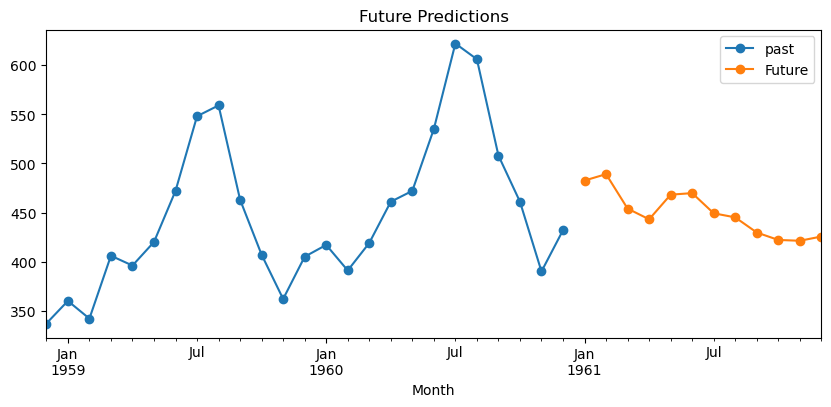

In [27]:
plt.figure(figsize=(10,4))
df['#Passengers'].iloc[-25:].plot(label='past', marker='o')
forecast.plot(label='Future', marker='o')

plt.legend()
plt.title('Future Predictions')
plt.show()

## Feature importance



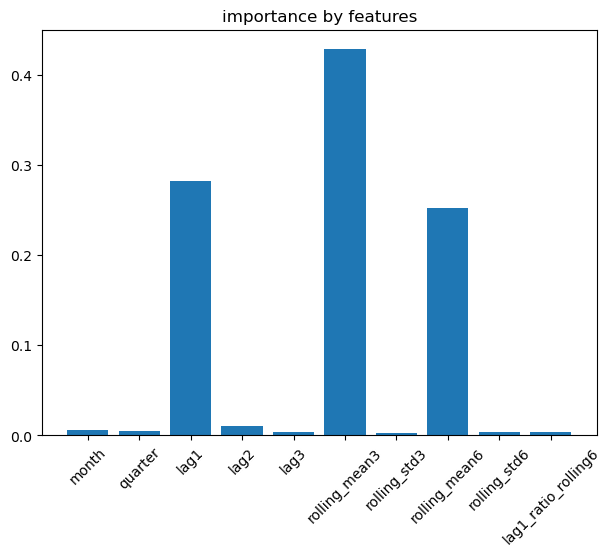

In [28]:
importances= final_model.feature_importances_
plt.bar( x_train.columns,  importances)

plt.title('importance by features')
plt.tight_layout()
plt.xticks(rotation= 45)
plt.show()

## Permutation importance

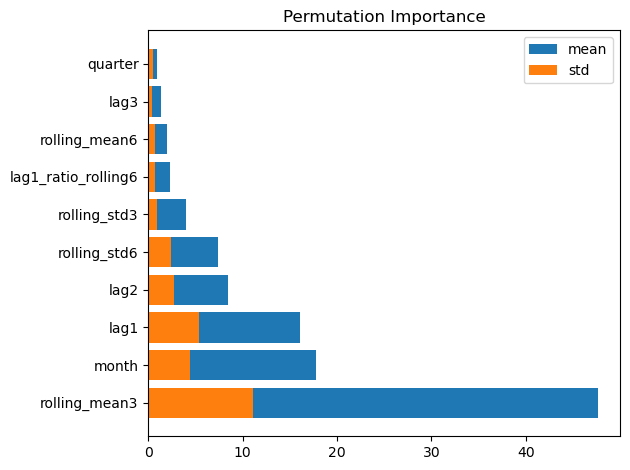

In [29]:
result_pi= permutation_importance(final_model, x_test, y_test,
                              scoring='neg_mean_absolute_error',
                              n_repeats=30,
                              n_jobs= -1)

features =  {
          'features': x_test.columns,
          'importance_mean': result_pi.importances_mean,
          'importance_std': result_pi.importances_std
        }
p_imp= pd.DataFrame(features)
p_imp=p_imp.sort_values('importance_mean', ascending=False)

plt.barh(p_imp['features'], p_imp['importance_mean'], label="mean")
plt.barh(p_imp['features'], p_imp['importance_std'], label='std')
plt.title('Permutation Importance')

plt.legend()
plt.tight_layout()
plt.show()

## Partial dependence

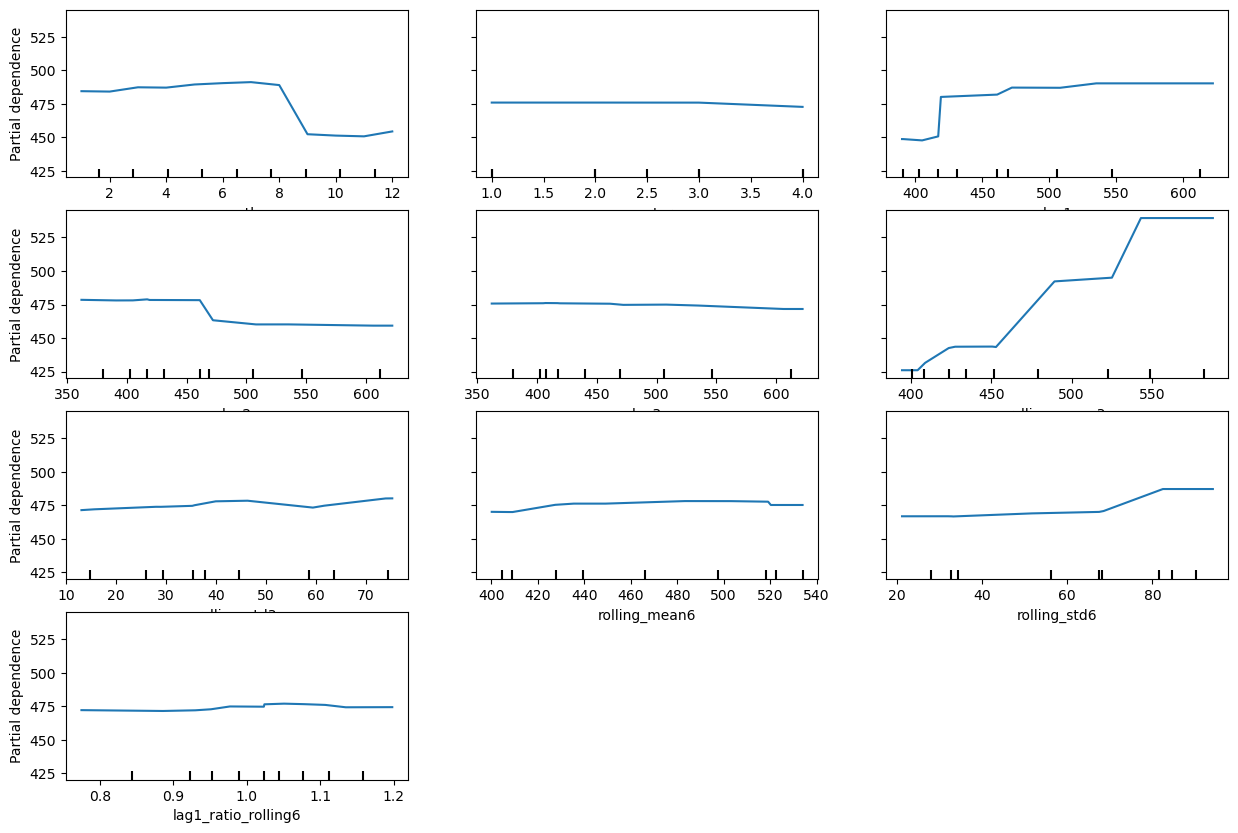

In [30]:
fig,axes= plt.subplots(figsize=(15,10))
PartialDependenceDisplay.from_estimator(final_model, x_test,
                                        kind= 'average',
                                        features= list(x_test.columns),
                                        feature_names= list(x_test.columns),
                                        grid_resolution= 50,
                                        n_cols= 3,
                                        ax= axes)
plt.show()

## Saving the model

In [31]:
joblib.dump(final_model, r"C:\Users\MINE\Desktop\Air passenger prediction\models\xgboost.pkl")

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\models\\xgboost.pkl']